# Phase 3 — final model training and D1 scoring

Run the cells in order. This notebook is the retained executable source for final model fitting, D1 scoring, and numerical regression checks.


In [1]:
"""Dependency-light final Phase 3 models and spatial-validation helpers."""

from __future__ import annotations

import numpy as np
from pathlib import Path
import sys
for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'outputs' / 'Data center' / 'TN').is_dir():
        ROOT = _candidate
        break
else:
    raise FileNotFoundError('Run from the project or a child directory.')
_support = ROOT / 'TN' / 'model' / 'notebook_support'
if str(_support) not in sys.path:
    sys.path.insert(0, str(_support))
from tn_common import sigmoid, weighted_auc
from phase3_data import empirical_percentile, make_training_table as _make_training_table


def soft_threshold(value, threshold):
    return np.sign(value) * np.maximum(np.abs(value) - threshold, 0.0)


def fit_elastic_net_logistic(x, y, sample_weight, alpha=0.5, lmbda=0.05, max_iter=4000, tol=1e-8):
    """Fit penalized logistic regression on already standardized predictors."""
    x, y, weight = np.asarray(x, float), np.asarray(y, float), np.asarray(sample_weight, float)
    total_weight = weight.sum()
    spectral = np.linalg.svd(x, compute_uv=False)[0] if x.size else 1.0
    step = 1.0 / (0.25 * spectral * spectral / total_weight + lmbda * (1 - alpha) + 1e-8)
    intercept, coef = 0.0, np.zeros(x.shape[1])
    for _ in range(max_iter):
        probability = sigmoid(intercept + x @ coef)
        residual = weight * (probability - y) / total_weight
        next_intercept = intercept - step * residual.sum()
        gradient = x.T @ residual + lmbda * (1 - alpha) * coef
        next_coef = soft_threshold(coef - step * gradient, step * lmbda * alpha)
        if max(abs(next_intercept - intercept), np.max(np.abs(next_coef - coef), initial=0.0)) < tol:
            intercept, coef = next_intercept, next_coef
            break
        intercept, coef = next_intercept, next_coef
    return {'kind': 'elastic_net', 'intercept': float(intercept), 'coef': coef, 'alpha': float(alpha), 'lambda': float(lmbda)}


def predict_elastic_net(x, model):
    return model['intercept'] + np.asarray(x, float) @ np.asarray(model['coef'], float)


def spatial_group_kfold(groups):
    groups = np.asarray(groups)
    for held_out in sorted(np.unique(groups), key=str):
        test = np.flatnonzero(groups == held_out)
        train = np.flatnonzero(groups != held_out)
        yield train, test, held_out


def fit_kmeans(x, k, seed=4701, starts=12, max_iter=250):
    x = np.asarray(x, float)
    rng = np.random.default_rng(seed)
    best = None
    for _ in range(starts):
        centers = x[rng.choice(len(x), k, replace=False)].copy()
        for __ in range(max_iter):
            distance2 = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            labels = distance2.argmin(axis=1)
            updated = np.vstack([x[labels == j].mean(axis=0) if np.any(labels == j) else centers[j] for j in range(k)])
            if np.allclose(updated, centers):
                break
            centers = updated
        inertia = float(((x - centers[labels]) ** 2).sum())
        if best is None or inertia < best['inertia']:
            best = {'kind': 'kmeans', 'centers': centers, 'inertia': inertia, 'k': int(k)}
    return best


def assign_kmeans(x, model):
    distance2 = ((np.asarray(x)[:, None, :] - np.asarray(model['centers'])[None, :, :]) ** 2).sum(axis=2)
    labels = distance2.argmin(axis=1)
    return labels, np.sqrt(distance2[np.arange(len(labels)), labels])


def robust_pca(x, variance_target=0.80):
    raw = np.log1p(np.asarray(x, float))
    median = np.median(raw, axis=0)
    iqr = np.quantile(raw, .75, axis=0) - np.quantile(raw, .25, axis=0)
    fallback = raw.std(axis=0)
    scale = np.where(iqr > 0, iqr, np.where(fallback > 0, fallback, 1.0))
    z = (raw - median) / scale
    _, singular, components = np.linalg.svd(z, full_matrices=False)
    explained = singular ** 2 / max(len(z) - 1, 1)
    explained = explained / explained.sum()
    n_components = max(2, int(np.searchsorted(np.cumsum(explained), variance_target) + 1))
    return {'median': median, 'scale': scale, 'components': components[:n_components], 'explained': explained[:n_components], 'n_components': n_components}, z @ components[:n_components].T


def transform_pca(x, model):
    return ((np.log1p(np.asarray(x, float)) - model['median']) / model['scale']) @ model['components'].T


def fit_pls_logistic(x, y, sample_weight, n_components=3, alpha=.15, lmbda=.05):
    """PLS-style supervised latent factors followed by an elastic-net logistic model."""
    x = np.asarray(x, float).copy()
    target = np.asarray(y, float).copy() - np.average(y, weights=sample_weight)
    weights, loadings, scores = [], [], []
    for _ in range(min(n_components, x.shape[1])):
        w = x.T @ (sample_weight * target)
        if np.linalg.norm(w) < 1e-12:
            break
        w /= np.linalg.norm(w)
        t = x @ w
        p = x.T @ (sample_weight * t) / max(np.sum(sample_weight * t * t), 1e-12)
        q = np.sum(sample_weight * target * t) / max(np.sum(sample_weight * t * t), 1e-12)
        weights.append(w); loadings.append(p); scores.append(t)
        x -= np.outer(t, p)
        target -= q * t
    w = np.column_stack(weights)
    p = np.column_stack(loadings)
    latent = np.column_stack(scores)
    logistic = fit_elastic_net_logistic(latent, y, sample_weight, alpha=alpha, lmbda=lmbda)
    return {'kind': 'pls_logistic', 'weights': w, 'loadings': p, 'logistic': logistic, 'n_components': latent.shape[1]}


def predict_pls_logistic(x, model):
    x = np.asarray(x, float).copy()
    latent = []
    weights = np.asarray(model['weights'], float)
    loadings = np.asarray(model['loadings'], float)
    for j in range(model['n_components']):
        t = x @ weights[:, j]
        latent.append(t)
        x -= np.outer(t, loadings[:, j])
    return predict_elastic_net(np.column_stack(latent), model['logistic'])


def spline_basis(x, knots):
    columns = [x]
    for knot in knots:
        columns.append(np.maximum(x - knot, 0.0))
    return np.column_stack(columns)


def fit_spline_logistic(x, y, sample_weight, top_features=6, alpha=.7, lmbda=.1):
    x = np.asarray(x, float)
    y_centered = np.asarray(y, float) - np.average(y, weights=sample_weight)
    association = np.abs((x * sample_weight[:, None]).T @ y_centered)
    selected = np.argsort(association)[-min(top_features, x.shape[1]):]
    knots = [np.quantile(x[:, j], [.25, .5, .75]) for j in selected]
    basis = np.column_stack([spline_basis(x[:, j], knot) for j, knot in zip(selected, knots)])
    logistic = fit_elastic_net_logistic(basis, y, sample_weight, alpha=alpha, lmbda=lmbda)
    return {'kind': 'spline_logistic', 'selected': selected, 'knots': knots, 'logistic': logistic}


def predict_spline_logistic(x, model):
    x = np.asarray(x, float)
    basis = np.column_stack([spline_basis(x[:, j], knot) for j, knot in zip(model['selected'], model['knots'])])
    return predict_elastic_net(basis, model['logistic'])


def fit_boosted_stumps(x, y, sample_weight, rounds=12, learning_rate=.05, min_leaf=24):
    """Strongly constrained logistic gradient boosting with single-feature stumps."""
    x, y, weight = np.asarray(x, float), np.asarray(y, float), np.asarray(sample_weight, float)
    intercept = float(np.log(np.average(y, weights=weight) / (1 - np.average(y, weights=weight))))
    score, stumps = np.repeat(intercept, len(y)), []
    for _ in range(rounds):
        residual = y - sigmoid(score)
        best = None
        for feature in range(x.shape[1]):
            for threshold in np.unique(np.quantile(x[:, feature], [.15, .30, .50, .70, .85])):
                left = x[:, feature] <= threshold
                if left.sum() < min_leaf or (~left).sum() < min_leaf:
                    continue
                left_value = np.average(residual[left], weights=weight[left])
                right_value = np.average(residual[~left], weights=weight[~left])
                gain = np.sum(weight * (np.where(left, left_value, right_value) ** 2))
                if best is None or gain > best[0]:
                    best = gain, feature, float(threshold), float(left_value), float(right_value)
        if best is None:
            break
        _, feature, threshold, left_value, right_value = best
        update = np.where(x[:, feature] <= threshold, left_value, right_value)
        score += learning_rate * update
        stumps.append({'feature': feature, 'threshold': threshold, 'left': left_value, 'right': right_value})
    return {'kind': 'boosted_stumps', 'intercept': intercept, 'stumps': stumps, 'learning_rate': learning_rate}


def predict_boosted_stumps(x, model):
    score = np.repeat(model['intercept'], len(x)).astype(float)
    for stump in model['stumps']:
        score += model['learning_rate'] * np.where(np.asarray(x)[:, stump['feature']] <= stump['threshold'], stump['left'], stump['right'])
    return score


import sys, types
_final_model_module = types.ModuleType('final_model')
_final_model_module.__dict__.update(globals())
sys.modules['final_model'] = _final_model_module


In [2]:
"""Reproducible Phase 3 final multi-location data-center scoring pipeline."""

from __future__ import annotations

import json
import re
from hashlib import sha256
from pathlib import Path
from zipfile import ZIP_DEFLATED, ZipFile, ZipInfo

import numpy as np
import pandas as pd

from final_model import (assign_kmeans, fit_boosted_stumps, fit_elastic_net_logistic,
                         fit_kmeans, fit_pls_logistic, fit_spline_logistic,
                         predict_boosted_stumps, predict_elastic_net,
                         predict_pls_logistic, predict_spline_logistic, robust_pca,
                         spatial_group_kfold, transform_pca, weighted_auc)

FROZEN_SHA = '112d6db67d7f4f9e74fa8edde3406937e1f8eb7145e9bc04a64e7030cf1d3e03'
FEATURES = ['dist_transmission_any_km','dist_transmission_100kv_km','dist_transmission_230kv_km','max_voltage_within_25km_kv','transmission_owner_count_25km','dist_major_road_km','dist_interstate_km','dist_surface_water_flowline_km','named_flowlines_within_25km','degree_institutions_50km','cip11_completions_50km','cip14_completions_50km','degree_institutions_100km','cip11_completions_100km','cip14_completions_100km','county_total_employment','county_total_establishments','information_sector_employment','information_sector_establishments','professional_scientific_employment','professional_scientific_establishments']


def standardize(train, apply):
    raw_train, raw_apply = np.log1p(train.to_numpy(float)), np.log1p(apply.to_numpy(float))
    mean, scale = raw_train.mean(0), raw_train.std(0)
    scale[scale == 0] = 1.0
    return (raw_train - mean) / scale, (raw_apply - mean) / scale, mean, scale


def candidate_fit(name, x, y, w):
    if name == 'elastic_net': return fit_elastic_net_logistic(x, y, w, alpha=.65, lmbda=.06)
    if name == 'pls_logistic': return fit_pls_logistic(x, y, w, n_components=3, alpha=.2, lmbda=.05)
    if name == 'spline_logistic': return fit_spline_logistic(x, y, w, top_features=6, alpha=.75, lmbda=.10)
    if name == 'boosted_stumps': return fit_boosted_stumps(x, y, w, rounds=12, learning_rate=.05, min_leaf=24)
    raise ValueError(name)


def candidate_predict(name, x, model):
    return {'elastic_net': predict_elastic_net, 'pls_logistic': predict_pls_logistic,
            'spline_logistic': predict_spline_logistic, 'boosted_stumps': predict_boosted_stumps}[name](x, model)


empirical_rank = lambda values: np.asarray(empirical_percentile(values))

def json_ready(value):
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, (np.floating, np.integer)): return value.item()
    if isinstance(value, dict): return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [json_ready(v) for v in value]
    return value


def make_training_table(sites, domain, background, scenario, draw):
    return _make_training_table(sites, domain, background, scenario, draw, FEATURES)


def write_score_map(frame, path):
    from tn_common import point_map
    point_map(frame, longitude='centroid_lon', latitude='centroid_lat', value='final_score', title='Phase 3 final empirical-affinity score', path=Path(path))

def normalize_xlsx(path):
    """Stabilize archive timestamps and core metadata for the released hash."""
    with ZipFile(path) as source:
        entries = [(entry.filename, source.read(entry.filename)) for entry in source.infolist()]
    with ZipFile(path, "w", compression=ZIP_DEFLATED, compresslevel=9) as target:
        for name, content in entries:
            if name == "docProps/core.xml":
                content = re.sub(rb">[^<]+</dcterms:created>", b">1980-01-01T00:00:00Z</dcterms:created>", content)
                content = re.sub(rb">[^<]+</dcterms:modified>", b">1980-01-01T00:00:00Z</dcterms:modified>", content)
            entry = ZipInfo(name, date_time=(1980, 1, 1, 0, 0, 0))
            entry.compress_type = ZIP_DEFLATED
            entry.external_attr = 0o600 << 16
            target.writestr(entry, content)


def run(project_root: str | Path):
    root = Path(project_root)
    phase2 = root / 'outputs/Data center/TN/model/phase 2/dataset/phase2_model_dataset.xlsx'
    results = root / 'outputs/Data center/TN/model/phase 3/results'; figures = results / 'figures'
    results.mkdir(parents=True, exist_ok=True); figures.mkdir(exist_ok=True)
    assert sha256(phase2.read_bytes()).hexdigest() == FROZEN_SHA
    sites = pd.read_excel(phase2, sheet_name='Presence_Sites')
    domain = pd.read_excel(phase2, sheet_name='Domain_Cells').query('d1_feasible == True').reset_index(drop=True)
    background = pd.read_excel(phase2, sheet_name='Background_Samples')
    assert len(domain) == 4391 and domain[FEATURES].notna().all().all()
    names = ['elastic_net','pls_logistic','spline_logistic','boosted_stumps']
    runs = []
    for scenario in ('primary','weighted','strict'):
        for draw in range(1,21):
            table = make_training_table(sites, domain, background, scenario, draw)
            for train_ix, test_ix, held_out in spatial_group_kfold(table.grand_region.to_numpy()):
                train, test = table.iloc[train_ix], table.iloc[test_ix]
                x_train, x_test, _, _ = standardize(train[FEATURES], test[FEATURES])
                for name in names:
                    model = candidate_fit(name, x_train, train.label.to_numpy(), train.sample_weight.to_numpy())
                    auc = weighted_auc(test.label, candidate_predict(name, x_test, model), test.sample_weight)
                    runs.append({'scenario':scenario,'draw':draw,'held_out_region':held_out,'candidate':name,'held_out_auc':auc})
    runs = pd.DataFrame(runs)
    fold_summary = runs.groupby(['scenario','candidate','held_out_region'], as_index=False).agg(median_auc=('held_out_auc','median'),p05_auc=('held_out_auc',lambda x:x.quantile(.05)),runs=('draw','size'))
    primary = fold_summary.query("scenario == 'primary'")
    selection = primary.groupby('candidate', as_index=False).agg(worst_fold_median=('median_auc','min'),worst_fold_p05=('p05_auc','min'))
    complexity = {'elastic_net':0,'pls_logistic':1,'spline_logistic':2,'boosted_stumps':3}
    selection['complexity'] = selection.candidate.map(complexity)
    winner = selection.sort_values(['worst_fold_median','worst_fold_p05','complexity'], ascending=[False,False,True]).iloc[0].candidate
    candidate_draw_models = {name: [] for name in names}
    raw_scores = []
    for draw in range(1,21):
        table = make_training_table(sites, domain, background, 'primary', draw)
        x_train, x_d1, mean, scale = standardize(table[FEATURES], domain[FEATURES])
        for name in names:
            model = candidate_fit(name, x_train, table.label.to_numpy(), table.sample_weight.to_numpy())
            candidate_draw_models[name].append({'draw':draw,'feature_mean':mean,'feature_scale':scale,'model':model})
        raw_scores.append(candidate_predict(winner, x_d1, candidate_draw_models[winner][-1]['model']))
    raw_scores = np.vstack(raw_scores)
    prediction = domain[['cell_id','centroid_lat','centroid_lon','grand_region']].copy()
    prediction['final_raw_score'] = np.median(raw_scores, axis=0)
    prediction['final_score'] = empirical_rank(prediction.final_raw_score)
    rank_draws = np.vstack([empirical_rank(x) for x in raw_scores])
    prediction['score_p05'] = np.quantile(rank_draws,.05,axis=0); prediction['score_p95'] = np.quantile(rank_draws,.95,axis=0)
    prediction['score_iqr'] = np.quantile(rank_draws,.75,axis=0)-np.quantile(rank_draws,.25,axis=0)
    prediction['rank'] = prediction.final_score.rank(ascending=False, method='min').astype(int)
    pca, pcs = robust_pca(domain[FEATURES]); cluster = fit_kmeans(pcs, k=2, seed=4701, starts=20)
    labels, distance = assign_kmeans(pcs, cluster)
    prediction['grid_regime'] = [f'R{i+1}' for i in labels]; prediction['regime_distance'] = distance
    prediction['novelty_threshold_95'] = prediction.groupby('grid_regime').regime_distance.transform(lambda x:x.quantile(.95))
    prediction['novelty_flag'] = prediction.regime_distance > prediction.novelty_threshold_95
    weights = {'phase2_sha256':FROZEN_SHA,'features':FEATURES,'winner':winner,'selection':selection.to_dict('records'),'candidate_primary_draw_models':candidate_draw_models,'grid_unsupervised':{'pca':pca,'kmeans':cluster},'score_reference_raw':np.sort(prediction.final_raw_score.to_numpy()).tolist()}
    weight_path = results / 'phase3_final_model_weights.json'; weight_path.write_text(json.dumps(json_ready(weights), indent=2), encoding='utf-8')
    output = results / 'phase3_final_multilocation_scoring.xlsx'
    with pd.ExcelWriter(output, engine='openpyxl') as writer:
        pd.DataFrame([{'phase2_sha256':FROZEN_SHA,'winner':winner,'features':len(FEATURES),'spatial_k_folds':3,'primary_draws':20,'purpose':'Primary-only model selection and D1 grid scoring.'}]).to_excel(writer, sheet_name='Model card', index=False)
        selection.to_excel(writer, sheet_name='Model selection', index=False); fold_summary.to_excel(writer, sheet_name='Fold metrics', index=False); runs.to_excel(writer, sheet_name='All K-fold runs', index=False); prediction.to_excel(writer, sheet_name='D1 final scores', index=False)
    normalize_xlsx(output)
    write_score_map(prediction, figures / 'phase3_final_score_map.png')
    return {'winner':winner,'weights':weight_path,'workbook':output,'prediction':prediction}


_train_model_module = types.ModuleType('train_final_model')
_train_model_module.__dict__.update(globals())
sys.modules['train_final_model'] = _train_model_module


## Run the Primary-only model


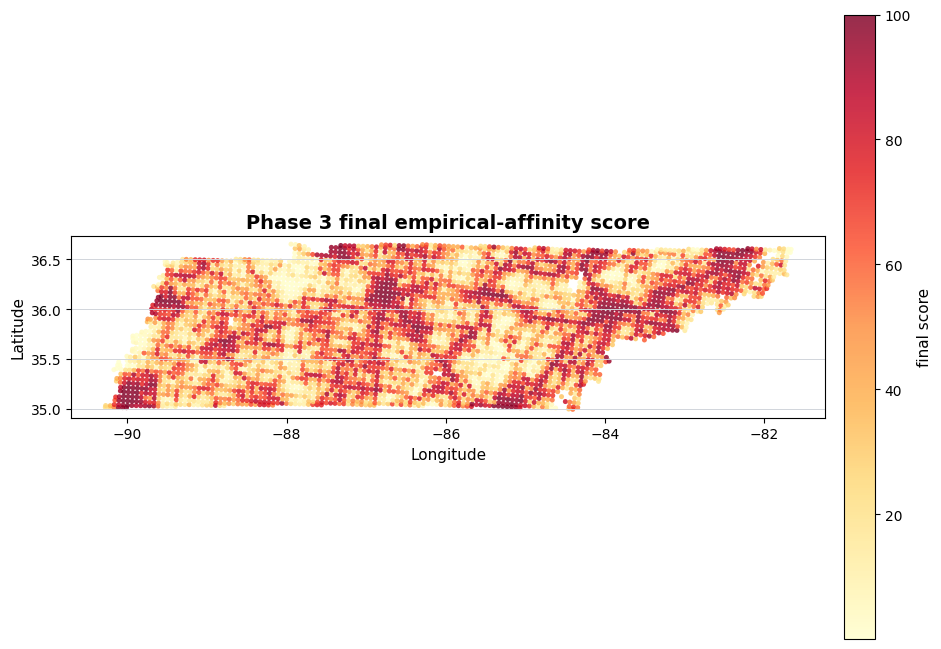

Selected model: pls_logistic


,cell_id,centroid_lat,centroid_lon,grand_region,final_raw_score,final_score,score_p05,score_p95,score_iqr,rank,grid_regime,regime_distance,novelty_threshold_95,novelty_flag
0,TN5K-0001,35.012277,-90.278346,west,-4.102286,22.022318,17.306992,27.203371,5.847187,3425,R1,4.618221,4.244876,True
1,TN5K-0002,35.030268,-90.274280,west,-3.961324,26.349351,21.728536,32.086085,6.268504,3235,R1,4.553032,4.244876,True
2,TN5K-0003,35.011831,-90.224204,west,-4.023594,24.686859,21.630608,29.721020,4.702801,3308,R1,4.596405,4.244876,True
3,TN5K-0004,35.029035,-90.216507,west,-3.640882,37.303575,33.449100,43.230471,6.353906,2754,R1,4.386811,4.244876,True
4,TN5K-0005,35.390655,-90.170660,west,-5.314249,1.411979,1.057846,2.317240,0.512412,4330,R2,3.121280,4.327421,False


In [3]:
from pathlib import Path
import sys
for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'outputs' / 'Data center' / 'TN').is_dir():
        ROOT = _candidate
        break
else:
    raise FileNotFoundError('Run from the project or a child directory.')
_support = ROOT / 'TN' / 'model' / 'notebook_support'
if str(_support) not in sys.path:
    sys.path.insert(0, str(_support))

ROOT = ROOT
result = run(ROOT)
print('Selected model:', result['winner'])
result['prediction'].head()


## Visualize retained D1 results


## Numerical regression checks


In [5]:
import unittest

import numpy as np

from final_model import (
    assign_kmeans,
    fit_elastic_net_logistic,
    fit_kmeans,
    fit_pls_logistic,
    predict_pls_logistic,
    spatial_group_kfold,
)


class FinalModelTests(unittest.TestCase):
    def test_elastic_net_shrinks_irrelevant_feature(self):
        rng = np.random.default_rng(7)
        x = rng.normal(size=(160, 3))
        y = (x[:, 0] + rng.normal(scale=0.2, size=160) > 0).astype(int)
        model = fit_elastic_net_logistic(x, y, np.ones(len(y)), alpha=0.9, lmbda=0.25)
        self.assertEqual(model['coef'].shape, (3,))
        self.assertGreater(abs(model['coef'][0]), abs(model['coef'][1]))
        self.assertGreater(abs(model['coef'][0]), abs(model['coef'][2]))

    def test_spatial_folds_do_not_mix_held_out_group(self):
        groups = np.array(['west', 'west', 'middle', 'middle', 'east', 'east'])
        folds = list(spatial_group_kfold(groups))
        self.assertEqual(len(folds), 3)
        for train, test, held_out in folds:
            self.assertFalse(set(groups[train]) & set(groups[test]))
            self.assertTrue((groups[test] == held_out).all())

    def test_kmeans_assigns_every_row(self):
        x = np.array([[0.0, 0.0], [0.1, 0.0], [4.9, 5.1], [5.1, 5.0]])
        model = fit_kmeans(x, k=2, seed=11, starts=4)
        labels, distances = assign_kmeans(x, model)
        self.assertEqual(len(labels), len(x))
        self.assertTrue(np.isfinite(distances).all())

    def test_pls_prediction_accepts_json_round_trip_lists(self):
        rng = np.random.default_rng(13)
        x = rng.normal(size=(80, 4))
        y = (x[:, 0] - x[:, 1] > 0).astype(int)
        model = fit_pls_logistic(x, y, np.ones(len(y)), n_components=2)
        portable = {key: (value.tolist() if isinstance(value, np.ndarray) else value) for key, value in model.items()}
        portable['logistic'] = {key: (value.tolist() if isinstance(value, np.ndarray) else value) for key, value in model['logistic'].items()}
        self.assertEqual(len(predict_pls_logistic(x[:3], portable)), 3)


result = unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromTestCase(FinalModelTests))
assert result.wasSuccessful()


test_elastic_net_shrinks_irrelevant_feature (__main__.FinalModelTests.test_elastic_net_shrinks_irrelevant_feature) ... ok
test_kmeans_assigns_every_row (__main__.FinalModelTests.test_kmeans_assigns_every_row) ... ok
test_pls_prediction_accepts_json_round_trip_lists (__main__.FinalModelTests.test_pls_prediction_accepts_json_round_trip_lists) ... ok
test_spatial_folds_do_not_mix_held_out_group (__main__.FinalModelTests.test_spatial_folds_do_not_mix_held_out_group) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.008s

OK
